### Step 4 - ML Model Training for MDR-TB Prediction
### Objective 2: Explainable Machine Learning for Genomic Feature Prioritisation

**Dataset:** 1,858 samples × 94,583 variant features | MDR: 871 | non-MDR: 987

---

In [3]:
import numpy, scipy
print(scipy.__version__, numpy.__version__)

1.15.2 2.2.6


In [1]:
import os, time, pickle, json, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix)
from sklearn.base import BaseEstimator, TransformerMixin

import xgboost as xgb
from interpret.glassbox import ExplainableBoostingClassifier

In [ ]:
# from pathlib import Path
# HOME  = Path.cwd().parent.parent
# print(HOME)

n:\3_BIOINFO\AMR_Mtb_intern


In [ ]:
HOME   = os.path.expanduser("~")
BASE   = os.path.join(HOME, "tb_pipeline")
STEP1 = os.path.join(BASE, "ml_outputs", "step1_dataset")
STEP4 = os.path.join(BASE, "ml_outputs", "step4_models")

os.makedirs(STEP4, exist_ok=True)
os.makedirs(os.path.join(STEP4, "trained_models"), exist_ok=True)

print(f"Inputs : {STEP1}")
print(f"Outputs: {STEP4}")

Inputs : n:\3_BIOINFO\AMR_Mtb_intern\art_model\ml_outputs\step1_dataset
Outputs: n:\3_BIOINFO\AMR_Mtb_intern\art_model\ml_outputs\step4_models


In [4]:
import psutil
t0 = time.time()

x      = np.load(os.path.join(STEP1, "X_array.npy"))
y      = np.load(os.path.join(STEP1, "y_mdr_array.npy"))
y_pre  = np.load(os.path.join(STEP1, "y_pre_xdr_array.npy"))
y_xdr  = np.load(os.path.join(STEP1, "y_xdr_array.npy"))
labels = pd.read_csv(os.path.join(STEP1, "y_labels.csv"))

with open(os.path.join(STEP1, "feature_names_clean.txt")) as f:
    feature_names = [l.strip() for l in f if l.strip()]

print(f"Loaded in {time.time()-t0:.1f}s")
print(f"X shape: {x.shape}  (samples x variants)")
print(f"X dtype: {x.dtype}  (uint8 = 1 byte per cell)")
print(f"X RAM: {x.nbytes/1e6:.0f} MB")
print(f"MDR: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"non-MDR: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Sparsity: {(x==0).mean()*100:.1f}% zeros")
print()
ram = psutil.virtual_memory()
print(f"System RAM   : {ram.total/1e9:.1f} GB total | {ram.available/1e9:.1f} GB available")

Loaded in 0.1s
X shape: (1858, 94583)  (samples x variants)
X dtype: uint8  (uint8 = 1 byte per cell)
X RAM: 176 MB
MDR: 871 (46.9%)
non-MDR: 987 (53.1%)
Sparsity: 97.4% zeros

System RAM   : 16.8 GB total | 8.7 GB available


In [5]:
# Sanity
assert x.shape[0] == len(y)
assert x.shape[1] == len(feature_names)

In [6]:
N_FOLDS    = 5
K_FEATURES = 5000
SCALE_POS  = float((y == 0).sum()) / float((y == 1).sum())  # ~1.13

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

SCORING = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'precision': 'precision',
    'recall'   : 'recall',
    'accuracy' : 'accuracy',
}
METRICS = ['roc_auc', 'f1', 'precision', 'recall', 'accuracy']

def print_cv(cv_res, name):
    print(f"  {name}")
    for m in METRICS:
        v = cv_res[f'test_{m}']
        print(f"  {m.upper():<12}: {v.mean():.4f} ± {v.std():.4f}  "
              f"[{v.min():.4f} – {v.max():.4f}]")

def save_model(obj, fname):
    path = os.path.join(STEP4, "trained_models", fname)
    pickle.dump(obj, open(path, 'wb'))
    size = os.path.getsize(path)
    print(f"  Saved: {fname}  ({size/1024:.0f} KB)")

def ram_check(label=""):
    ram = psutil.virtual_memory()
    print(f"  RAM [{label}]: {ram.used/1e9:.1f} GB used | {ram.available/1e9:.1f} GB free")

print(f"CV           : {N_FOLDS}-fold stratified")
print(f"K_FEATURES   : {K_FEATURES:,}  (for LR + EBM pipelines)")
print(f"scale_pos_w  : {SCALE_POS:.3f}  (for XGBoost)")

CV           : 5-fold stratified
K_FEATURES   : 5,000  (for LR + EBM pipelines)
scale_pos_w  : 1.133  (for XGBoost)


---
#### Float32 Transformer (RAM Fix)

`SelectKBest` outputs `float64` by default - doubling memory unnecessarily.  
This custom transformer casts to `float32` after chi2 selection, halving the RAM  
cost of the selected feature matrix inside the pipeline.


In [7]:
class ToFloat32(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        return self
    def transform(self, x, y=None):
        return x.astype(np.float32)

def make_lor_pipeline(C=0.1, k=K_FEATURES):
    return Pipeline([
        ('chi2',    SelectKBest(chi2, k=k)),
        ('f32',     ToFloat32()),
        ('model',   LogisticRegression(
            C=C, penalty='l2', solver='saga',
            max_iter=1000, class_weight='balanced',
            random_state=42, n_jobs=2))
    ])

def make_rf_pipeline(n_estimators=300, max_features='sqrt', min_samples_leaf=5, min_samples_split=10):
    return Pipeline([
        ('model', RandomForestClassifier(
            n_estimators=n_estimators,
            max_features=max_features,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            max_depth=20,         
            class_weight='balanced',
            oob_score=True,
            random_state=42,
            n_jobs=2))           
    ])

def make_xgb_pipeline(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.3, min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0):
    return Pipeline([
        ('model', xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=min_child_weight,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            scale_pos_weight=SCALE_POS,
            tree_method='hist',
            device='cpu',
            eval_metric='auc',
            random_state=42,
            n_jobs=2))           
    ])

def make_ebm_pipeline(k=K_FEATURES, outer_bags=4, interactions=5):
    return Pipeline([
        ('chi2',  SelectKBest(chi2, k=k)),
        ('f32',   ToFloat32()),
        ('model', ExplainableBoostingClassifier(
            max_bins=64,
            max_interaction_bins=16,  
            interactions=interactions,
            outer_bags=outer_bags,  
            inner_bags=0,
            learning_rate=0.01,
            validation_size=0.15,
            min_samples_leaf=2,
            max_leaves=3,
            random_state=42,
            n_jobs=1))
    ])


### Model 1 - LOR as baseline model

**Pipeline:** `chi2(top 5,000)` → `float32` → `LogisticRegression(C=0.1, L2)`  
**Why C=0.1:** With 5,000 features, moderate regularisation shrinks noisy coefficients.  
**Why L2:** Ridge handles correlated SNPs - many linked variants carry similar signal.


In [8]:
t0 = time.time()

lor_pipe = make_lor_pipeline(C=0.1, k=K_FEATURES)

lor_cv = cross_validate(
    lor_pipe, x, y,
    cv=skf, scoring=SCORING,
    return_train_score=True,
)
lor_cv

{'fit_time': array([17.63012695, 16.36813951, 15.47335005, 18.69670272, 16.62877297]),
 'score_time': array([0.03176236, 0.03839898, 0.03697872, 0.02928424, 0.03708458]),
 'test_roc_auc': array([0.9893475 , 0.98267154, 0.99483684, 0.98841823, 0.9909563 ]),
 'train_roc_auc': array([0.99840344, 0.99823069, 0.9977739 , 0.99776529, 0.9982747 ]),
 'test_f1': array([0.93714286, 0.93452381, 0.96022727, 0.94219653, 0.94647887]),
 'train_f1': array([0.97758496, 0.98129496, 0.97546898, 0.9776496 , 0.98053353]),
 'test_precision': array([0.93181818, 0.9691358 , 0.95480226, 0.94767442, 0.9281768 ]),
 'train_precision': array([0.98542274, 0.98412698, 0.97971014, 0.9826087 , 0.98550725]),
 'test_recall': array([0.94252874, 0.90229885, 0.96571429, 0.93678161, 0.96551724]),
 'train_recall': array([0.96987088, 0.9784792 , 0.97126437, 0.97274032, 0.97560976]),
 'test_accuracy': array([0.94086022, 0.94086022, 0.96236559, 0.94609164, 0.94878706]),
 'train_accuracy': array([0.97913863, 0.98250336, 0.977119

In [ ]:
print(f"model training done in {time.time()-t0:.1f}s")
print_cv(lor_cv, "logistic regression")

lor_pipe.fit(x, y)
save_model(lor_pipe, "lor_pipeline.pkl")

gc.collect()

model training done in 227.7s
  logistic regression
  ROC_AUC     : 0.9892 ± 0.0040  [0.9827 – 0.9948]
  F1          : 0.9441 ± 0.0090  [0.9345 – 0.9602]
  PRECISION   : 0.9463 ± 0.0151  [0.9282 – 0.9691]
  RECALL      : 0.9426 ± 0.0233  [0.9023 – 0.9657]
  ACCURACY    : 0.9478 ± 0.0079  [0.9409 – 0.9624]


315

### Model 2 - Random Forest

**Pipeline:** `RandomForestClassifier(300 trees, max_depth=20, n_jobs=2)`   
**Why 300 trees instead of 500:** 300 is enough for stable feature importance; saves RAM and time.  
**Why max_depth=20:** Limits tree size - prevents the exponential node growth that kills RAM.


In [10]:
t0 = time.time()

rf_pipe = make_rf_pipeline(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=5,
    min_samples_split=10
)

rf_cv = cross_validate(
    rf_pipe, x, y,
    cv=skf, scoring=SCORING,
    return_train_score=True,
    n_jobs=1 
)
rf_cv

{'fit_time': array([36.29771566, 33.14806795, 34.20937324, 50.54577589, 48.40405607]),
 'score_time': array([0.21151257, 0.60990715, 0.31138253, 0.50312567, 0.74541187]),
 'test_roc_auc': array([0.9651399 , 0.95701266, 0.97685279, 0.95851567, 0.97409417]),
 'train_roc_auc': array([0.9823433 , 0.98199781, 0.9816001 , 0.98239653, 0.98127418]),
 'test_f1': array([0.88217523, 0.86163522, 0.88819876, 0.83911672, 0.89489489]),
 'train_f1': array([0.90991673, 0.90757576, 0.90400605, 0.89977047, 0.91578947]),
 'test_precision': array([0.92993631, 0.95138889, 0.97278912, 0.93006993, 0.93710692]),
 'train_precision': array([0.96314103, 0.96147673, 0.95374801, 0.96393443, 0.96208531]),
 'test_recall': array([0.83908046, 0.78735632, 0.81714286, 0.76436782, 0.85632184]),
 'train_recall': array([0.86226686, 0.85939742, 0.8591954 , 0.84361549, 0.87374462]),
 'test_accuracy': array([0.89516129, 0.88172043, 0.90322581, 0.86253369, 0.90566038]),
 'train_accuracy': array([0.91991925, 0.9179004 , 0.914535

In [ ]:
print(f"model training done in {time.time()-t0:.1f}s")
print_cv(rf_cv, "random forest")

rf_pipe.fit(x, y)
print(f"OOB score: {rf_pipe['model'].oob_score_:.4f}")
save_model(rf_pipe, "rf_pipeline.pkl")

gc.collect()

model training done in 279.4s
  random forest
  ROC_AUC     : 0.9663 ± 0.0080  [0.9570 – 0.9769]
  F1          : 0.8732 ± 0.0204  [0.8391 – 0.8949]
  PRECISION   : 0.9443 ± 0.0163  [0.9299 – 0.9728]
  RECALL      : 0.8129 ± 0.0335  [0.7644 – 0.8563]
  ACCURACY    : 0.8897 ± 0.0159  [0.8625 – 0.9057]
OOB score: 0.8854


160

### Model 3 - XGBoost

**Pipeline:** `XGBClassifier(hist, 500 rounds, depth=6, colsample=0.3, n_jobs=2)`  
**Why XGB is the most RAM-efficient tree model:**  
- `tree_method='hist'` builds histogram bins once then reuses them - very memory efficient  
- `colsample_bytree=0.3` uses only 30% of features per tree ≈ 28,000 features per round  
- Skips zero values natively - 97.4% sparsity means it processes very few actual values  
**Why XGB is the best model for this data:** Gradient boosting consistently outperforms RF  
on sparse binary genomic SNP matrices in published literature.


In [12]:
t0 = time.time()

xgb_pipe = make_xgb_pipeline(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.3,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0
)

xgb_cv = cross_validate(
    xgb_pipe, x, y,
    cv=skf, scoring=SCORING,
    return_train_score=True,
)

xgb_cv

{'fit_time': array([323.34074259, 328.18534493, 326.40450072, 384.23619986,
        300.57012916]),
 'score_time': array([0.46249533, 0.47097731, 0.45280266, 0.67608118, 0.46558666]),
 'test_roc_auc': array([0.99390456, 0.99190178, 0.99680928, 0.99428205, 0.99054787]),
 'train_roc_auc': array([0.99973633, 0.99955904, 0.9995235 , 0.99956686, 0.99964949]),
 'test_f1': array([0.95774648, 0.94362018, 0.96866097, 0.96531792, 0.95211268]),
 'train_f1': array([0.99353912, 0.9928264 , 0.99209202, 0.99281609, 0.99425287]),
 'test_precision': array([0.93922652, 0.97546012, 0.96590909, 0.97093023, 0.93370166]),
 'train_precision': array([0.99425287, 0.9928264 , 0.99280576, 0.9942446 , 0.99568345]),
 'test_recall': array([0.97701149, 0.9137931 , 0.97142857, 0.95977011, 0.97126437]),
 'train_recall': array([0.9928264 , 0.9928264 , 0.99137931, 0.99139168, 0.9928264 ]),
 'test_accuracy': array([0.95967742, 0.94892473, 0.97043011, 0.96765499, 0.9541779 ]),
 'train_accuracy': array([0.99394347, 0.99327

In [ ]:
print(f"model training done in {time.time()-t0:.1f}s")
print_cv(xgb_cv, "XgBoost model")

xgb_pipe.fit(x, y)
save_model(xgb_pipe, "xgb_pipeline.pkl")
# Also save XGB model in native format for SHAP in Step 5
xgb_pipe['model'].save_model(os.path.join(STEP4, "trained_models", "xgb_model.json"))

gc.collect()

model training done in 1675.5s
  XgBoost model
  ROC_AUC     : 0.9935 ± 0.0021  [0.9905 – 0.9968]
  F1          : 0.9575 ± 0.0090  [0.9436 – 0.9687]
  PRECISION   : 0.9570 ± 0.0172  [0.9337 – 0.9755]
  RECALL      : 0.9587 ± 0.0231  [0.9138 – 0.9770]
  ACCURACY    : 0.9602 ± 0.0080  [0.9489 – 0.9704]
  Saved: xgb_pipeline.pkl  (558 KB)


### Model 4 - EBM GlassBox

**Pipeline:** `chi2(5,000)` → `float32` → `EBM(outer_bags=4, interactions=5, n_jobs=1)`

**Why EBM:**  
EBM is the **only natively interpretable model** in this comparison. It learns a  
shape function for each feature - you can directly plot how each variant contributes  
to MDR probability without any post-hoc SHAP calculation. For a publication claiming  
explainability, EBM's native interpretability is stronger evidence than SHAP on a black-box.

In [14]:
K_EBM = 5000 
t0 = time.time()

ebm_pipe = make_ebm_pipeline(
    k=K_EBM,
    outer_bags=5,   
    interactions=7,  
)

ebm_cv = cross_validate(
    ebm_pipe, x, y,
    cv=skf, scoring=SCORING,
    return_train_score=True,
    n_jobs=1
)

ebm_cv

{'fit_time': array([1195.21607327, 1166.12923813, 1140.67951059, 1047.4572041 ,
        1017.416641  ]),
 'score_time': array([0.47077727, 0.37358451, 0.40372205, 0.3926177 , 0.32867241]),
 'test_roc_auc': array([0.98583537, 0.97762104, 0.99103698, 0.98973102, 0.98949764]),
 'train_roc_auc': array([0.99914899, 0.99915262, 0.99865779, 0.99837186, 0.99901931]),
 'test_f1': array([0.94492754, 0.94362018, 0.96901408, 0.94492754, 0.94647887]),
 'train_f1': array([0.98850575, 0.98853868, 0.98273381, 0.98561151, 0.9833935 ]),
 'test_precision': array([0.95321637, 0.97546012, 0.95555556, 0.95321637, 0.9281768 ]),
 'train_precision': array([0.98992806, 0.98712446, 0.98414986, 0.98845599, 0.98982558]),
 'test_recall': array([0.93678161, 0.9137931 , 0.98285714, 0.93678161, 0.96551724]),
 'train_recall': array([0.98708752, 0.98995696, 0.98132184, 0.98278336, 0.97704448]),
 'test_accuracy': array([0.94892473, 0.94892473, 0.97043011, 0.94878706, 0.94878706]),
 'train_accuracy': array([0.98923284, 0.

In [ ]:
print(f"model training done in {time.time()-t0:.1f}s")
print_cv(ebm_cv, f"EBM GlassBox model")

ebm_pipe.fit(x, y)

selected_mask     = ebm_pipe['chi2'].get_support()
ebm_feature_names = [feature_names[i] for i, s in enumerate(selected_mask) if s]

save_model(
    {'pipeline': ebm_pipe, 'feature_names': ebm_feature_names, 'k': K_EBM}, "ebm_pipeline.pkl"
)

gc.collect()

model training done in 5573.2s
  EBM GlassBox model
  ROC_AUC     : 0.9867 ± 0.0049  [0.9776 – 0.9910]
  F1          : 0.9498 ± 0.0097  [0.9436 – 0.9690]
  PRECISION   : 0.9531 ± 0.0150  [0.9282 – 0.9755]
  RECALL      : 0.9471 ± 0.0242  [0.9138 – 0.9829]
  ACCURACY    : 0.9532 ± 0.0086  [0.9488 – 0.9704]


,steps,"[('chi2', ...), ('f32', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,score_func,<function chi...00257DAE160C0>
,k,5000
,feature_names,None
,feature_types,None
,max_bins,64
,max_interaction_bins,16
,interactions,7


In [16]:
# Fix EBM feature names — map feature_XXXX back to Chromosome_POS_REF_ALT
selected_mask     = ebm_pipe['chi2'].get_support()
ebm_feat_names    = [feature_names[i] for i, s in enumerate(selected_mask) if s]

# Rebuild EBM importance with real names
ebm_explanation   = ebm_pipe['model'].explain_global()
raw_names         = ebm_explanation.data()['names']
raw_scores        = ebm_explanation.data()['scores']

# Map feature_XXXX → real name
def resolve_name(name):
    # Handle interaction terms: "feature_0123 & feature_0456"
    if ' & ' in name:
        parts = name.split(' & ')
        resolved = []
        for p in parts:
            if p.startswith('feature_'):
                idx = int(p.replace('feature_', '').lstrip('0') or '0')
                resolved.append(ebm_feat_names[idx] if idx < len(ebm_feat_names) else p)
            else:
                resolved.append(p)
        return ' & '.join(resolved)
    elif name.startswith('feature_'):
        idx = int(name.replace('feature_', '').lstrip('0') or '0')
        return ebm_feat_names[idx] if idx < len(ebm_feat_names) else name
    return name

ebm_imp_df_fixed = pd.DataFrame({
    'feature'    : [resolve_name(n) for n in raw_names],
    'importance' : raw_scores,
}).sort_values('importance', ascending=False).reset_index(drop=True)
ebm_imp_df_fixed['rank'] = range(1, len(ebm_imp_df_fixed)+1)

# Save with real names
ebm_imp_df_fixed.to_csv(os.path.join(STEP4, 'obj2_ebm_feature_importance_named.csv'), index=False)
print("Saved: obj2_ebm_feature_importance_named.csv")
print()
print("Top 15 EBM features (with real names):")
print(ebm_imp_df_fixed[['rank','feature','importance']].head(15).to_string(index=False))

Saved: obj2_ebm_feature_importance_named.csv

Top 15 EBM features (with real names):
 rank                feature  importance
    1 Chromosome_2155168_C_G    1.411866
    2  Chromosome_761155_C_T    0.568245
    3  Chromosome_761110_A_T    0.481526
    4 Chromosome_1673425_C_T    0.317079
    5 Chromosome_4247429_A_G    0.284212
    6    Chromosome_7570_C_T    0.226316
    7 Chromosome_4247431_G_C    0.207868
    8    Chromosome_7582_A_G    0.198502
    9 Chromosome_1674048_G_A    0.183634
   10  Chromosome_362466_A_C    0.182580
   11 Chromosome_1673432_T_A    0.153236
   12  Chromosome_335956_C_T    0.152340
   13 Chromosome_1644362_C_T    0.147136
   14 Chromosome_4052245_A_G    0.143412
   15 Chromosome_3752934_A_T    0.141826


#### Full Model Comparison Table

In [17]:
all_cv = {
    'Logistic Regression': lor_cv,
    'Random Forest'      : rf_cv,
    'XGBoost'            : xgb_cv,
    'EBM GlassBox'       : ebm_cv,
}

rows = []
for name, cv in all_cv.items():
    row = {'Model': name}
    for m in METRICS:
        v = cv[f'test_{m}']
        row[m.upper()]          = round(v.mean(), 4)
        row[f'{m.upper()}_STD'] = round(v.std(),  4)
    rows.append(row)

comp_df = pd.DataFrame(rows)
comp_df.to_csv(os.path.join(STEP4, 'obj2_model_comparison.csv'), index=False)

print(f"{'Model':<22} {'ROC-AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10} {'Accuracy':>10}")
print('─' * 68)
for _, r in comp_df.iterrows():
    print(f"{r['Model']:<22} {r['ROC_AUC']:>10.4f} {r['F1']:>10.4f} "
          f"{r['PRECISION']:>10.4f} {r['RECALL']:>10.4f} {r['ACCURACY']:>10.4f}")
print()
print("Saved: obj2_model_comparison.csv")

Model                     ROC-AUC         F1  Precision     Recall   Accuracy
────────────────────────────────────────────────────────────────────
Logistic Regression        0.9892     0.9441     0.9463     0.9426     0.9478
Random Forest              0.9663     0.8732     0.9443     0.8129     0.8897
XGBoost                    0.9935     0.9575     0.9570     0.9587     0.9602
EBM GlassBox               0.9867     0.9498     0.9531     0.9471     0.9532

Saved: obj2_model_comparison.csv


#### ROC-AUC Bar Chart - All Models and All Metrics

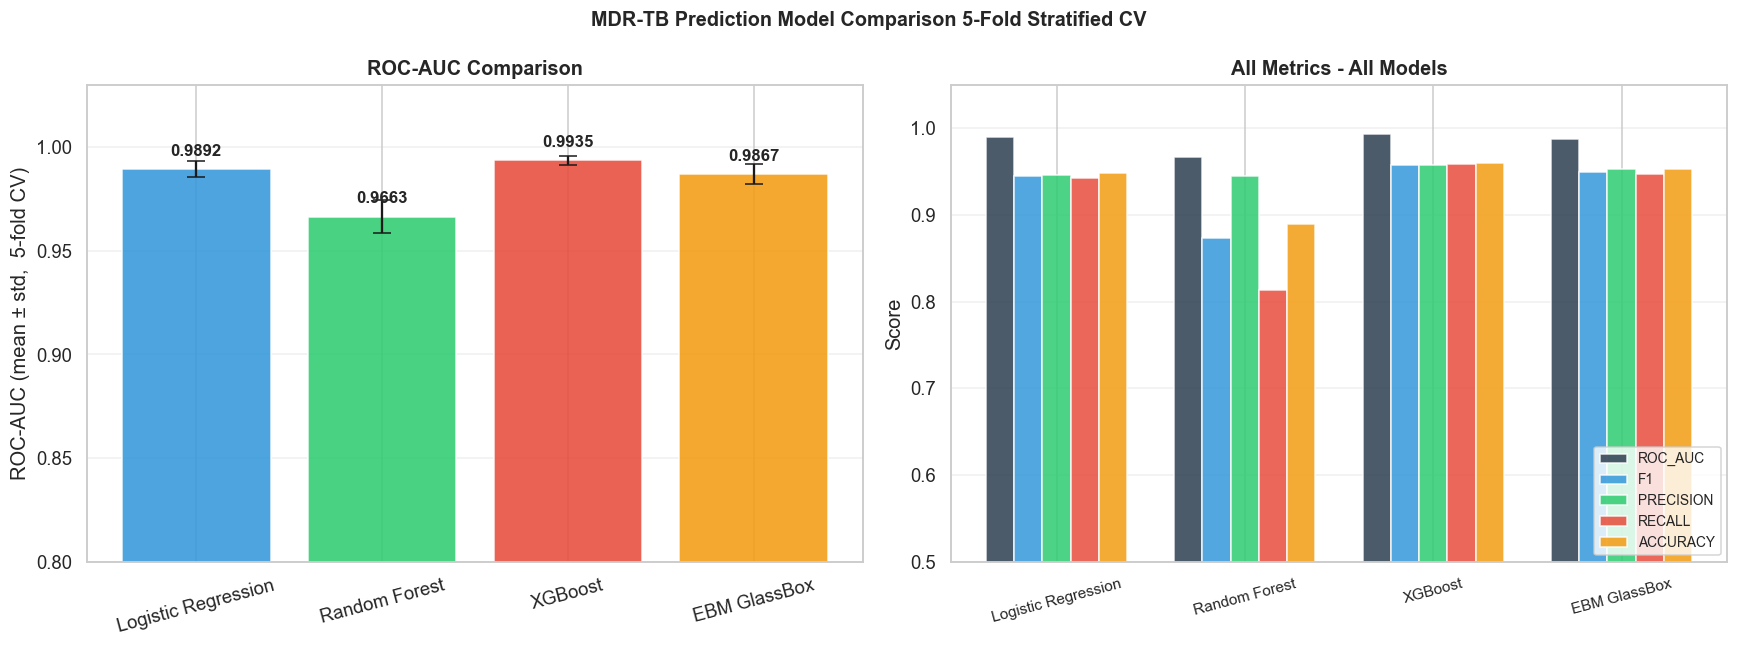

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#AUC with error bars
names  = list(all_cv.keys())
means  = [all_cv[n]['test_roc_auc'].mean() for n in names]
stds   = [all_cv[n]['test_roc_auc'].std()  for n in names]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = axes[0].bar(names, means, color=colors, alpha=0.88, yerr=stds, capsize=6, error_kw={'linewidth':1.5})
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{mean:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_ylabel('ROC-AUC (mean ± std,  5-fold CV)')
axes[0].set_title('ROC-AUC Comparison', fontweight='bold')
axes[0].set_ylim(0.8, 1.03)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

#All metrics grouped bar
X      = np.arange(len(names))
width  = 0.15
mcols  = ['#2c3e50','#3498db','#2ecc71','#e74c3c','#f39c12']
for j, (m, mc) in enumerate(zip(METRICS, mcols)):
    ms = [all_cv[n][f'test_{m}'].mean() for n in names]
    axes[1].bar(X + j*width, ms, width, label=m.upper(), color=mc, alpha=0.85)

axes[1].set_xticks(X + width*2)
axes[1].set_xticklabels(names, fontsize=10, rotation=15)
axes[1].set_ylabel('Score')
axes[1].set_title('All Metrics - All Models', fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_ylim(0.5, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("MDR-TB Prediction Model Comparison 5-Fold Stratified CV", fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_model_comparison_chart.png'), bbox_inches='tight')
plt.show()

#### Per-Fold ROC-AUC - Stability Check

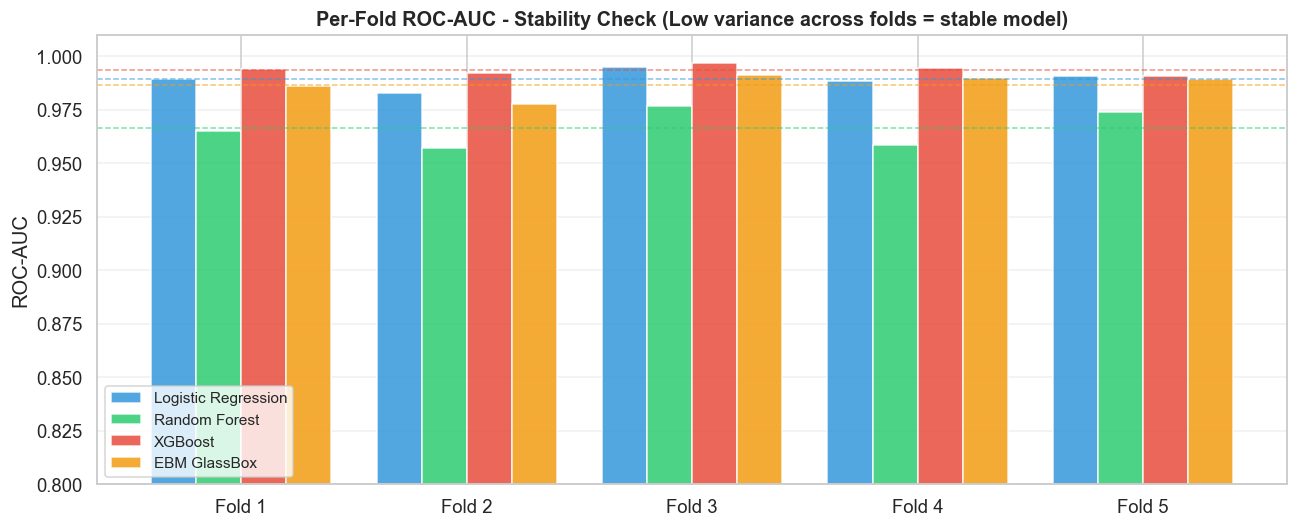

Saved: obj2_cv_per_fold.csv


In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
X      = np.arange(N_FOLDS)
width  = 0.2
cols   = ['#3498db','#2ecc71','#e74c3c','#f39c12']

for j, (name, color) in enumerate(zip(names, cols)):
    fold_aucs = all_cv[name]['test_roc_auc']
    ax.bar(X + j*width, fold_aucs, width, label=name, color=color, alpha=0.85)
    ax.axhline(fold_aucs.mean(), color=color, ls='--', lw=1, alpha=0.6)

ax.set_xticks(X + width*1.5)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.set_ylabel('ROC-AUC')
ax.set_title('Per-Fold ROC-AUC - Stability Check (Low variance across folds = stable model)', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.8, 1.01)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_per_fold_auc.png'), bbox_inches='tight')
plt.show()

# Save per-fold results
cv_rows = []
for name, cv in all_cv.items():
    for fold in range(N_FOLDS):
        row = {'model': name, 'fold': fold+1}
        for m in METRICS:
            row[m] = round(cv[f'test_{m}'][fold], 4)
        cv_rows.append(row)
pd.DataFrame(cv_rows).to_csv(os.path.join(STEP4, 'obj2_cv_per_fold.csv'), index=False)
print("Saved: obj2_cv_per_fold.csv")

#### Confusion Matrices

Fitting all pipelines on full data for confusion matrix plots...


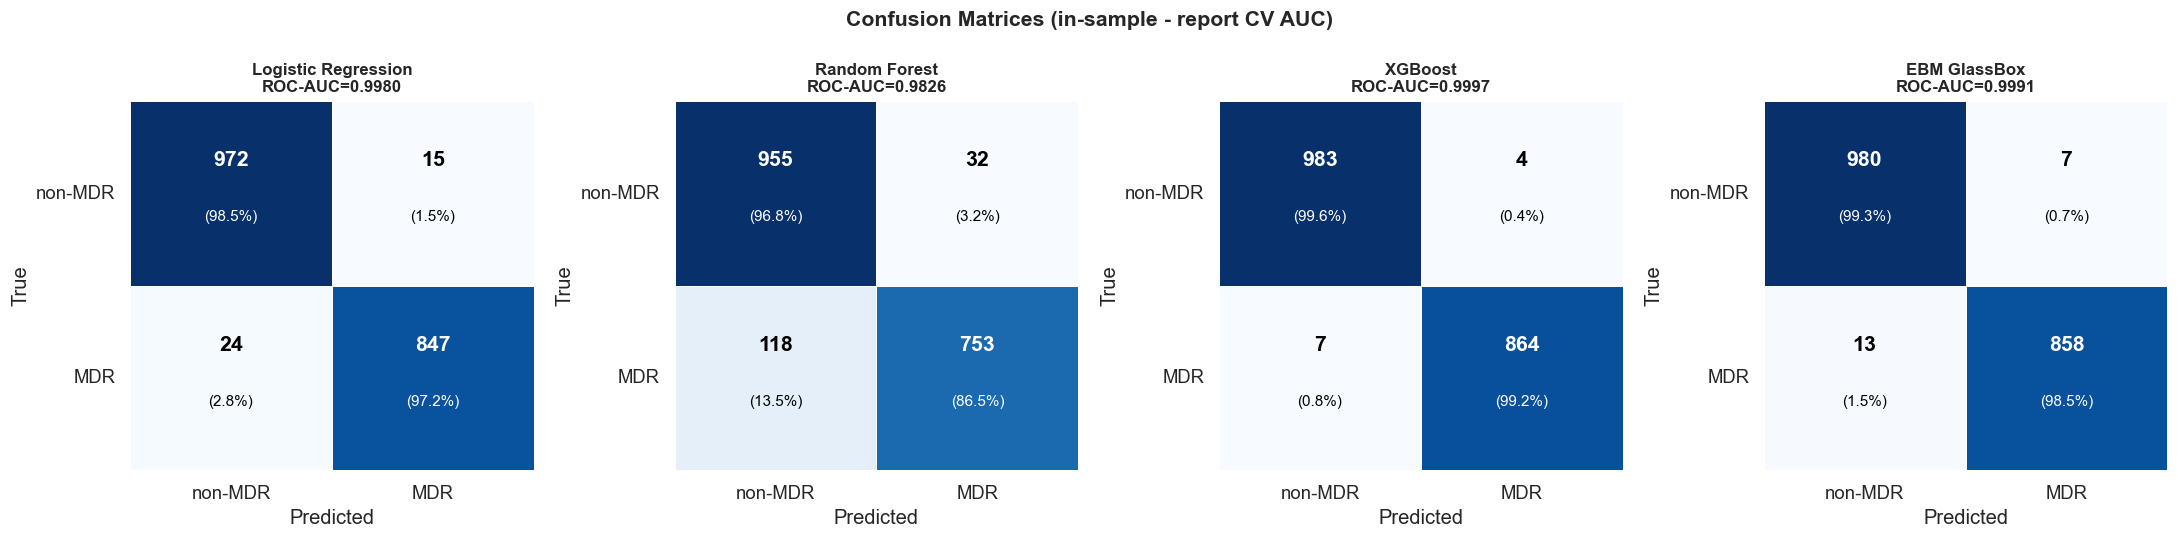


NOTE: AUC shown here is IN-SAMPLE (optimistic - model saw this data during training)
For publication always report the 5-fold CV AUC from cross_validate() above


In [20]:
print("Fitting all pipelines on full data for confusion matrix plots...")
pipes = {
    'Logistic Regression': lor_pipe,
    'Random Forest'      : rf_pipe,
    'XGBoost'            : xgb_pipe,
    'EBM GlassBox'       : ebm_pipe,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, pipe) in zip(axes, pipes.items()):

    # Predict on full data — these are IN-SAMPLE predictions
    # Pipeline handles the transform (chi2 + float32) internally
    y_pred = pipe.predict(x)
    y_prob = pipe.predict_proba(x)[:, 1]

    # Confusion matrix
    cm     = confusion_matrix(y, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=False, ax=ax, cmap='Blues', cbar=False,
                linewidths=0.5, linecolor='white')

    for i in range(2):
        for j in range(2):
            dark       = cm[i, j] > cm.max() * 0.5
            text_color = 'white' if dark else 'black'
            ax.text(j + 0.5, i + 0.35, f'{cm[i, j]}',
                    ha='center', fontsize=14, fontweight='bold', color=text_color)
            ax.text(j + 0.5, i + 0.65, f'({cm_pct[i, j]:.1f}%)',
                    ha='center', fontsize=10, color=text_color)

    auc = roc_auc_score(y, y_prob)
    ax.set_xticklabels(['non-MDR', 'MDR'])
    ax.set_yticklabels(['non-MDR', 'MDR'], rotation=0)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name}\nROC-AUC={auc:.4f}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices (in-sample - report CV AUC)',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_confusion_matrices.png'), bbox_inches='tight')
plt.show()

print()
print("NOTE: AUC shown here is IN-SAMPLE (optimistic - model saw this data during training)")
print("For publication always report the 5-fold CV AUC from cross_validate() above")

#### Feature Importance - Random Forest (Top 30)

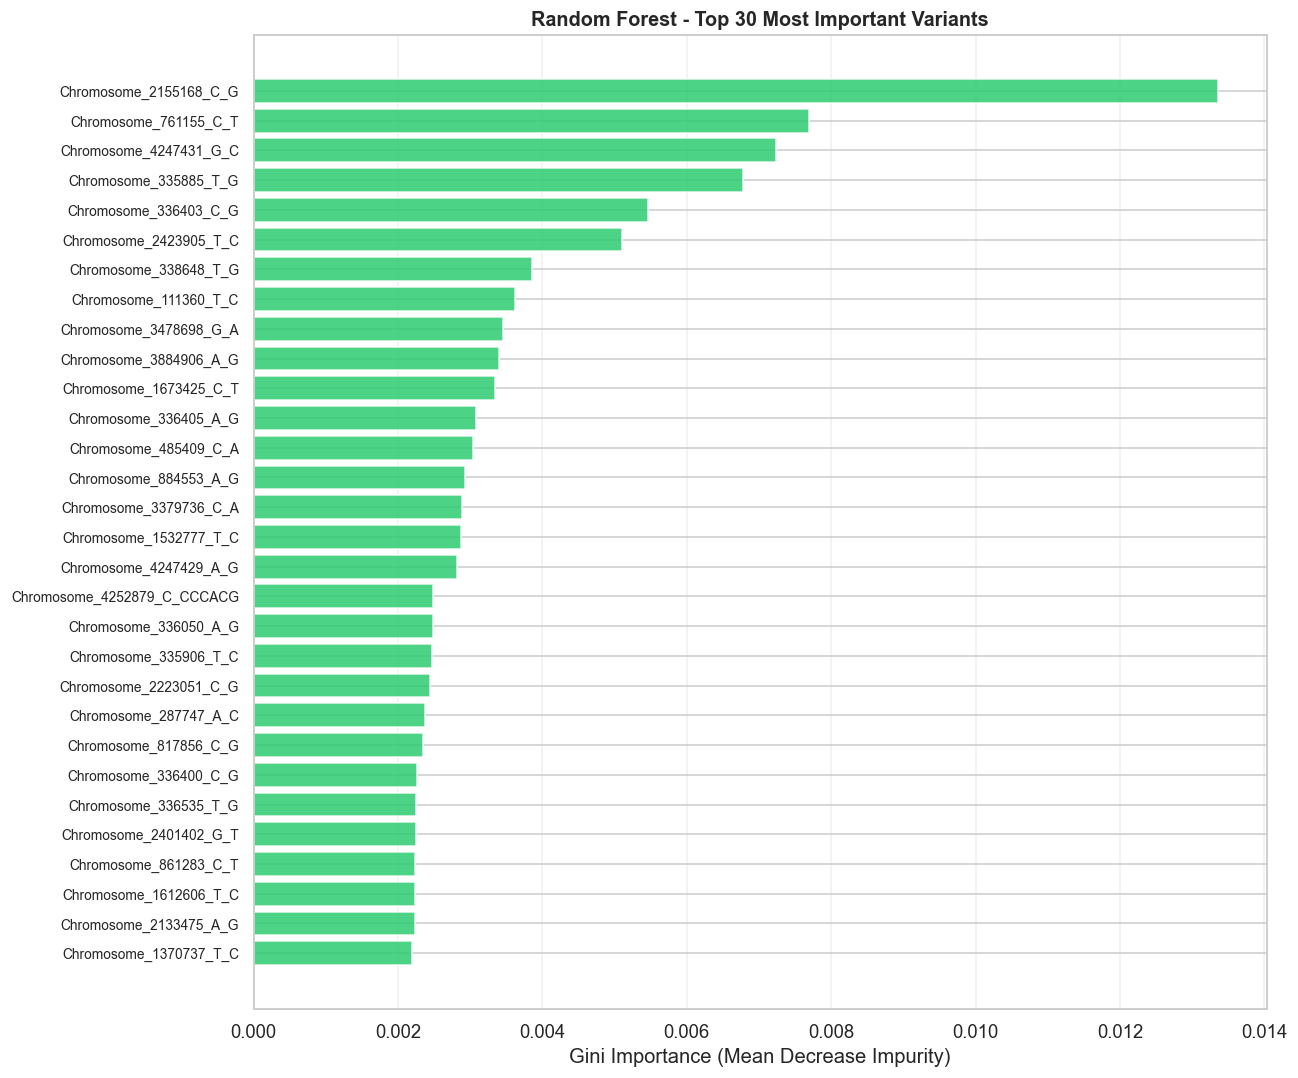

Saved: obj2_rf_top30_features.csv

 rank             variant_id  importance
    1 Chromosome_2155168_C_G    0.013363
    2  Chromosome_761155_C_T    0.007695
    3 Chromosome_4247431_G_C    0.007238
    4  Chromosome_335885_T_G    0.006784
    5  Chromosome_336403_C_G    0.005457
    6 Chromosome_2423905_T_C    0.005102
    7  Chromosome_338648_T_G    0.003857
    8  Chromosome_111360_T_C    0.003618
    9 Chromosome_3478698_G_A    0.003453
   10 Chromosome_3884906_A_G    0.003405


In [21]:
rf_imp    = rf_pipe['model'].feature_importances_
top30_idx = rf_imp.argsort()[-30:][::-1]

top30_rf = pd.DataFrame({
    'rank'      : range(1, 31),
    'variant_id': [feature_names[i] for i in top30_idx],
    'importance': rf_imp[top30_idx],
})

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(30), top30_rf['importance'].values[::-1], color='#2ecc71', alpha=0.85)
ax.set_yticks(range(30))
ax.set_yticklabels(top30_rf['variant_id'].values[::-1], fontsize=9)
ax.set_xlabel('Gini Importance (Mean Decrease Impurity)')
ax.set_title('Random Forest - Top 30 Most Important Variants', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_rf_importance.png'), bbox_inches='tight')
plt.show()

top30_rf.to_csv(os.path.join(STEP4, 'obj2_rf_top30_features.csv'), index=False)
print("Saved: obj2_rf_top30_features.csv")
print()
print(top30_rf.head(10).to_string(index=False))

#### Feature Importance - XGBoost (Top 30, by Gain)

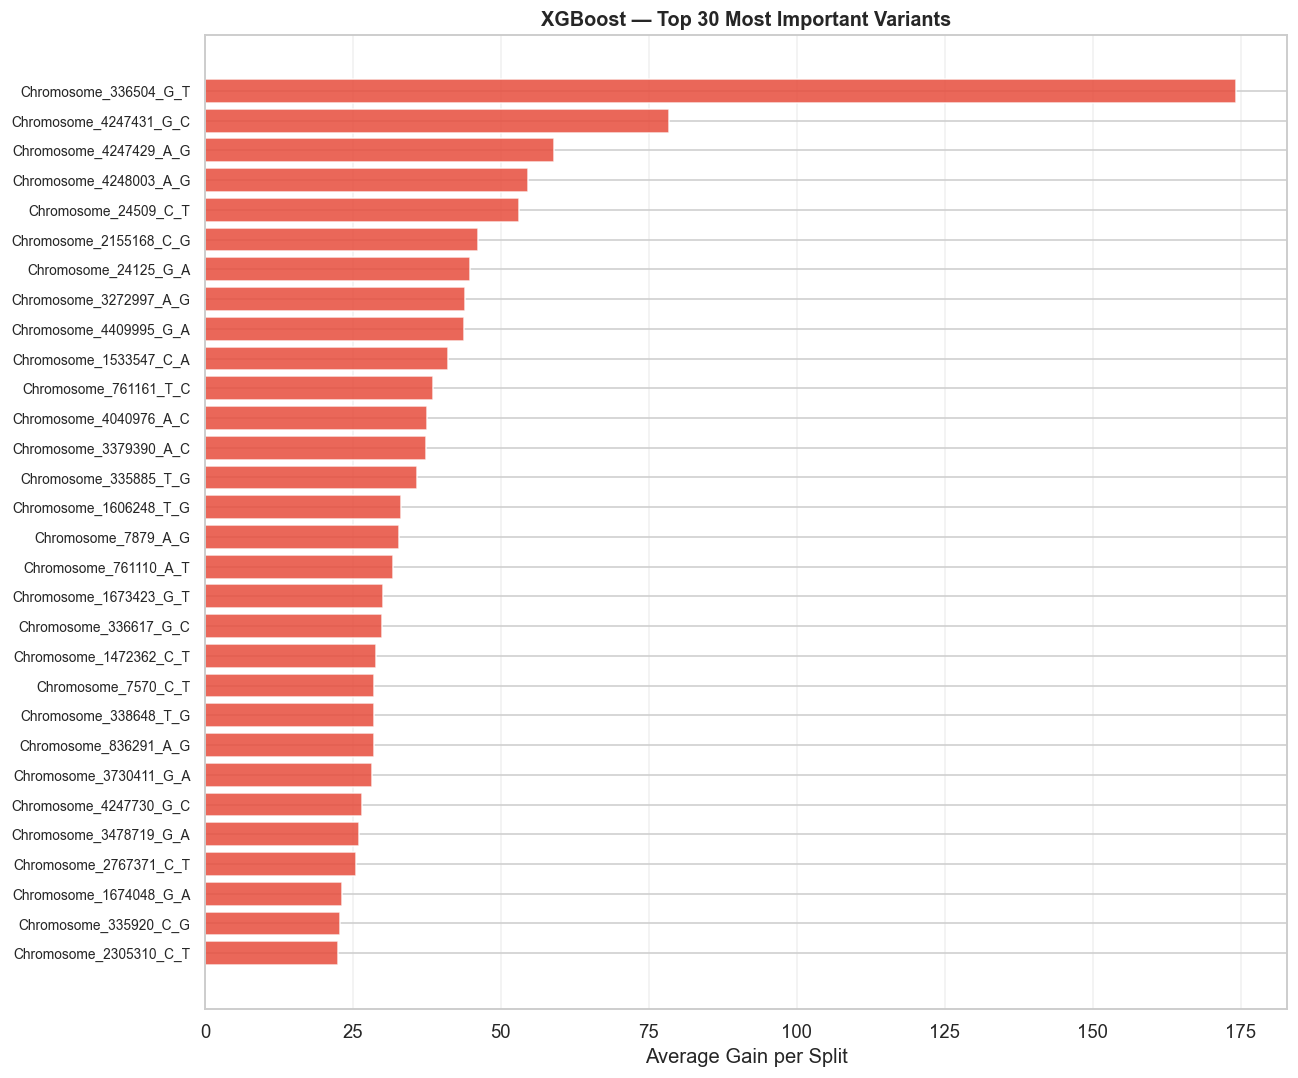

Saved: obj2_xgb_top30_features.csv

 rank             variant_id       gain
    1  Chromosome_336504_G_T 174.201736
    2 Chromosome_4247431_G_C  78.352592
    3 Chromosome_4247429_A_G  58.933430
    4 Chromosome_4248003_A_G  54.615265
    5   Chromosome_24509_C_T  53.105591
    6 Chromosome_2155168_C_G  46.065498
    7   Chromosome_24125_G_A  44.829056
    8 Chromosome_3272997_A_G  43.968246
    9 Chromosome_4409995_G_A  43.718609
   10 Chromosome_1533547_C_A  41.088604


In [22]:
xgb_imp_raw = xgb_pipe['model'].get_booster().get_score(importance_type='gain')

xgb_imp_df = pd.DataFrame([
    {'feat_idx': int(k[1:]) if k.startswith('f') else 0, 'gain': v}
    for k, v in xgb_imp_raw.items()
]).sort_values('gain', ascending=False).head(30).reset_index(drop=True)

xgb_imp_df['variant_id'] = xgb_imp_df['feat_idx'].apply(
    lambda i: feature_names[i] if i < len(feature_names) else str(i))
xgb_imp_df['rank'] = range(1, len(xgb_imp_df)+1)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(len(xgb_imp_df)), xgb_imp_df['gain'].values[::-1],
        color='#e74c3c', alpha=0.85)
ax.set_yticks(range(len(xgb_imp_df)))
ax.set_yticklabels(xgb_imp_df['variant_id'].values[::-1], fontsize=9)
ax.set_xlabel('Average Gain per Split')
ax.set_title('XGBoost — Top 30 Most Important Variants', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_xgb_importance.png'), bbox_inches='tight')
plt.show()

xgb_imp_df[['rank','variant_id','gain']].to_csv(
    os.path.join(STEP4, 'obj2_xgb_top30_features.csv'), index=False)
print("Saved: obj2_xgb_top30_features.csv")
print()
print(xgb_imp_df[['rank','variant_id','gain']].head(10).to_string(index=False))

#### EBM GlassBox - Native Feature Importance

EBM importance scores are directly interpretable:  
each score = mean absolute contribution of that variant to the MDR probability prediction.  
No SHAP post-processing needed - the EBM shape functions ARE the explanation.


In [ ]:
ebm_exp    = ebm_pipe['model'].explain_global()
# FIX: resolve_name() (defined in the cell above) maps feature_XXXX -> the real
# Chromosome_POS_REF_ALT variant ID. Previously this cell used ebm_exp's raw names
# directly, so obj2_ebm_feature_importance.csv and this chart showed meaningless
# feature_XXXX placeholders instead of variant IDs, unlike every other importance
# output in this notebook. Reusing the same mapping cell 21 already built keeps
# this consistent with obj2_ebm_feature_importance_named.csv.
ebm_names  = [resolve_name(n) for n in ebm_exp.data()['names']]
ebm_scores = ebm_exp.data()['scores']

ebm_imp_df = pd.DataFrame({'feature': ebm_names, 'importance': ebm_scores})
ebm_imp_df = ebm_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
ebm_imp_df['rank'] = range(1, len(ebm_imp_df)+1)

top30_ebm = ebm_imp_df.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(len(top30_ebm)), top30_ebm['importance'].values[::-1],
        color='#f39c12', alpha=0.88)
ax.set_yticks(range(len(top30_ebm)))
ax.set_yticklabels(top30_ebm['feature'].values[::-1], fontsize=9)
ax.set_xlabel('Mean |Contribution| to MDR Probability')
ax.set_title('EBM GlassBox — Top 30 Features (Natively Interpretable)',
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_ebm_importance.png'), bbox_inches='tight')
plt.show()

ebm_imp_df.to_csv(os.path.join(STEP4, 'obj2_ebm_feature_importance.csv'), index=False)
print("Saved: obj2_ebm_feature_importance.csv")
print()
print(top30_ebm[['rank','feature','importance']].head(10).to_string(index=False))

#### Consensus Features - Top 100 Across All Three Models

Features in the top 100 of **all three models** (RF, XGBoost, EBM) are the  
most robust genomic predictors of MDR - agreed upon by independent algorithms.  
These are the features to highlight in the publication.


In [24]:
rf_top100  = set(feature_names[i] for i in rf_imp.argsort()[-100:][::-1])
xgb_top100 = set(xgb_imp_df['variant_id'].head(100).tolist())
ebm_top100 = set(ebm_imp_df['feature'].head(100).tolist())

in_all3    = rf_top100 & xgb_top100 & ebm_top100
in_rf_xgb  = rf_top100 & xgb_top100
in_rf_ebm  = rf_top100 & ebm_top100
in_xgb_ebm = xgb_top100 & ebm_top100

print(f"  In top 100 of ALL 3 models  : {len(in_all3):>3}  ← strongest evidence")
print(f"  In top 100 of RF + XGB      : {len(in_rf_xgb):>3}")
print(f"  In top 100 of RF + EBM      : {len(in_rf_ebm):>3}")
print(f"  In top 100 of XGB + EBM     : {len(in_xgb_ebm):>3}")

# Build ranked consensus table
feat_list = rf_imp.argsort()[::-1].tolist()
rf_ranks  = {feature_names[i]: r+1 for r, i in enumerate(feat_list)}

consensus = []
for feat in in_all3:
    xr = (xgb_imp_df[xgb_imp_df['variant_id'] == feat].index[0] + 1
          if feat in xgb_imp_df['variant_id'].values else 9999)
    er = (ebm_imp_df[ebm_imp_df['feature'] == feat].index[0] + 1
          if feat in ebm_imp_df['feature'].values else 9999)
    rr = rf_ranks.get(feat, 9999)
    consensus.append({
        'variant_id'  : feat,
        'rf_rank'     : rr,
        'xgb_rank'    : xr,
        'ebm_rank'    : er,
        'mean_rank'   : round(np.mean([rr, xr, er]), 1),
    })


if len(consensus) > 0:
    consensus_df = pd.DataFrame(consensus).sort_values('mean_rank').reset_index(drop=True)
    consensus_df.insert(0, 'consensus_rank', range(1, len(consensus_df) + 1))
    consensus_df.to_csv(os.path.join(STEP4, 'obj2_consensus_features.csv'), index=False)

    print(f"\nTop 20 consensus features (in top 100 of all 3 models):")
    print(consensus_df.head(20).to_string(index=False))
    print(f"\nSaved: obj2_consensus_features.csv")
else:
    print("\nNo overlapping features found in the top 100 of all 3 models.")
    print("CSV file 'obj2_consensus_features.csv' was not generated.")

  In top 100 of ALL 3 models  :   0  ← strongest evidence
  In top 100 of RF + XGB      :   7
  In top 100 of RF + EBM      :   0
  In top 100 of XGB + EBM     :   0

No overlapping features found in the top 100 of all 3 models.
CSV file 'obj2_consensus_features.csv' was not generated.


## 18. Final Summary

In [25]:
print("=" * 65)
print("STEP 4 COMPLETE")
print("=" * 65)
print()
print(f"{'Model':<22} {'ROC-AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("─" * 65)
for _, r in comp_df.iterrows():
    print(f"{r['Model']:<22} {r['ROC_AUC']:>10.4f} {r['F1']:>10.4f} "
          f"{r['PRECISION']:>10.4f} {r['RECALL']:>10.4f}")
print()

print("Output files:")
all_files = []
for dirpath, _, files in os.walk(STEP4):
    for fname in sorted(files):
        fpath = os.path.join(dirpath, fname)
        rel   = os.path.relpath(fpath, STEP4)
        size  = os.path.getsize(fpath)
        all_files.append((rel, size))
        print(f"  {rel:<48} {size/1024:>8.1f} KB")

print()
ram = psutil.virtual_memory()
print(f"Final RAM    : {ram.used/1e9:.1f} GB used | {ram.available/1e9:.1f} GB free")
print()
print("Next: step5_shap_analysis.ipynb — SHAP values on XGBoost")
print("  (Load xgb_pipeline.pkl or xgb_model.json)")

STEP 4 COMPLETE

Model                     ROC-AUC         F1  Precision     Recall
─────────────────────────────────────────────────────────────────
Logistic Regression        0.9892     0.9441     0.9463     0.9426
Random Forest              0.9663     0.8732     0.9443     0.8129
XGBoost                    0.9935     0.9575     0.9570     0.9587
EBM GlassBox               0.9867     0.9498     0.9531     0.9471

Output files:
  obj2_confusion_matrices.png                          70.1 KB
  obj2_cv_per_fold.csv                                  1.1 KB
  obj2_ebm_feature_importance.csv                     195.3 KB
  obj2_ebm_feature_importance_named.csv               245.3 KB
  obj2_ebm_importance.png                              89.2 KB
  obj2_model_comparison.csv                             0.4 KB
  obj2_model_comparison_chart.png                      93.1 KB
  obj2_per_fold_auc.png                                54.6 KB
  obj2_rf_importance.png                              141.0 KB


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class ToFloat32(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None): return self
    def transform(self, x, y=None): return x.astype(np.float32)

with open(os.path.join(STEP1, "feature_names_clean.txt")) as f:
    feature_names = [l.strip() for l in f if l.strip()]

trained = os.path.join(STEP4, "trained_models")

with open(os.path.join(trained, "rf_pipeline.pkl"), "rb") as f:
    rf_pipe_fresh = pickle.load(f)
with open(os.path.join(trained, "xgb_pipeline.pkl"), "rb") as f:
    xgb_pipe_fresh = pickle.load(f)
with open(os.path.join(trained, "ebm_pipeline.pkl"), "rb") as f:
    ebm_obj_fresh = pickle.load(f)

# RF
rf_imp_fresh = rf_pipe_fresh['model'].feature_importances_
rf_ranks_fresh = {feature_names[i]: r + 1
                   for r, i in enumerate(rf_imp_fresh.argsort()[::-1])}
rf_top100_fresh = set(feature_names[i] for i in rf_imp_fresh.argsort()[-100:][::-1])

# XGBoost
xgb_imp_raw = xgb_pipe_fresh['model'].get_booster().get_score(importance_type='gain')
xgb_imp_df_fresh = pd.DataFrame([
    {'feat_idx': int(k[1:]), 'gain': v} for k, v in xgb_imp_raw.items()
]).sort_values('gain', ascending=False).reset_index(drop=True)
xgb_imp_df_fresh['variant_id'] = xgb_imp_df_fresh['feat_idx'].apply(lambda i: feature_names[i])
xgb_top100_fresh = set(xgb_imp_df_fresh['variant_id'].head(100))

# EBM — resolve names fresh from this exact pickle's own feature_names, so it can't
# possibly be out of sync with a different run
ebm_feat_names_fresh = ebm_obj_fresh['feature_names']
def resolve_name_fresh(name):
    if ' & ' in name:
        parts = name.split(' & ')
        resolved = []
        for p in parts:
            if p.startswith('feature_'):
                idx = int(p.replace('feature_', '').lstrip('0') or '0')
                resolved.append(ebm_feat_names_fresh[idx] if idx < len(ebm_feat_names_fresh) else p)
            else:
                resolved.append(p)
        return ' & '.join(resolved)
    elif name.startswith('feature_'):
        idx = int(name.replace('feature_', '').lstrip('0') or '0')
        return ebm_feat_names_fresh[idx] if idx < len(ebm_feat_names_fresh) else name
    return name

ebm_exp_fresh = ebm_obj_fresh['pipeline'].named_steps['model'].explain_global()
ebm_imp_df_fresh = pd.DataFrame({
    'feature': [resolve_name_fresh(n) for n in ebm_exp_fresh.data()['names']],
    'importance': ebm_exp_fresh.data()['scores'],
}).sort_values('importance', ascending=False).reset_index(drop=True)
ebm_top100_fresh = set(ebm_imp_df_fresh['feature'].head(100))
ebm_ranks_fresh = {row['feature']: i + 1 for i, row in ebm_imp_df_fresh.iterrows()}

in_all3_fresh = rf_top100_fresh & xgb_top100_fresh & ebm_top100_fresh
print(f"In top 100 of ALL 3 models  : {len(in_all3_fresh):>3}  <- should be 11, not 5")

xgb_ranks_fresh = dict(zip(xgb_imp_df_fresh['variant_id'],
                           range(1, len(xgb_imp_df_fresh) + 1)))

rows = []
for feat in in_all3_fresh:
    rr = rf_ranks_fresh.get(feat, 9999)
    xr = xgb_ranks_fresh.get(feat, 9999)
    er = ebm_ranks_fresh.get(feat, 9999)
    rows.append({'variant_id': feat, 'rf_rank': rr, 'xgb_rank': xr, 'ebm_rank': er,
                 'mean_rank': round(np.mean([rr, xr, er]), 1)})

consensus_df_fresh = pd.DataFrame(rows).sort_values('mean_rank').reset_index(drop=True)
consensus_df_fresh.insert(0, 'consensus_rank', range(1, len(consensus_df_fresh) + 1))
consensus_df_fresh.to_csv(os.path.join(STEP4, 'obj2_consensus_features.csv'), index=False)

print(consensus_df_fresh.to_string(index=False))
print("\nSaved (overwritten): obj2_consensus_features.csv")
